---
title: TRABAJO PRÁCTICO N° 4
subtitle: Clasificando pobres con la EPH, Metodos de Regularización y CART
author: Ricardo Javier Gutiérrez Vistín - Martín Gabriel Cargnel
date-format: "MMM, YYYY"
lang: es
execute:
  echo: true
  include: false
  fig-align: center
format:
  pdf:
    documentclass: scrartcl
    toc-depth: 2
    number-sections: true
---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import accuracy_score, recall_score, roc_curve, roc_auc_score, precision_score, f1_score

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV

Link al repositorio: https://github.com/mcargnel/Big-Data-UBA-Grupo-09/tree/main/TP4

{{< pagebreak >}}

In [3]:
respondieron = pd.read_parquet('/Users/mcargnel/Documents/mea/Big-Data-UBA-Grupo-001/TP4/data/respondieron.parquet')
norespondieron = pd.read_parquet('/Users/mcargnel/Documents/mea/Big-Data-UBA-Grupo-001/TP4/data/norespondieron.parquet')

In [4]:
respondieron_2025 = respondieron[respondieron['ano4'] == 2025].copy()
respondieron_2025 = respondieron_2025.reset_index(drop=True).drop(columns=['ano4'])
respondieron_2005 = respondieron[respondieron['ano4'] == 2005].copy()
respondieron_2005 = respondieron_2005.reset_index(drop=True).drop(columns=['ano4'])


norespondieron_2005 = norespondieron[norespondieron['ano4'] == 2005].copy()
norespondieron_2005 = norespondieron_2005.reset_index(drop=True).drop(columns=['ano4'])
norespondieron_2025 = norespondieron[norespondieron['ano4'] == 2025].copy()
norespondieron_2025 = norespondieron_2025.reset_index(drop=True).drop(columns=['ano4'])

In [5]:
X = respondieron_2025.drop(columns=['pobre'])
y = respondieron_2025['pobre']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 444)

# Modelo de Regresión Logística con Regularización: Ridge y LASSO

## Visualización

En la @fig-coefs-ridge-lasso se puede ver la evolución de los coeficientes de la regresión logística con las penalizaciones Lasso y Ridge. Como puede verse, a medida que la penalidad aumenta, los coeficientes tienden a cero. Sin embargo, puede notarse que Lasso sí trunca los coeficientes a cero, y es por eso que sirve para seleccionar variables; mientras que en Ridge se aprecia cómo se aproximan al cero, pero de forma más suave y sin llegar a anularse

In [7]:
sc = StandardScaler()

X_train_scaled = sc.fit_transform(X_train)

In [8]:
C_grid = np.logspace(-4, 4, 100)

coefs_lasso = []
coefs_ridge = []

for C in C_grid:

    log_reg_ridge = LogisticRegression(C=C, penalty='l2', solver='saga', max_iter=5000, random_state=42)
    log_reg_ridge.fit(X_train_scaled, y_train)
    coefs_ridge.append(log_reg_ridge.coef_.ravel())
    
    
    log_reg_lasso = LogisticRegression(C=C, penalty='l1', solver='saga', max_iter=5000, random_state=42)
    log_reg_lasso.fit(X_train_scaled, y_train)
    coefs_lasso.append(log_reg_lasso.coef_.ravel())

coefs_lasso = np.array(coefs_lasso)
coefs_ridge = np.array(coefs_ridge)

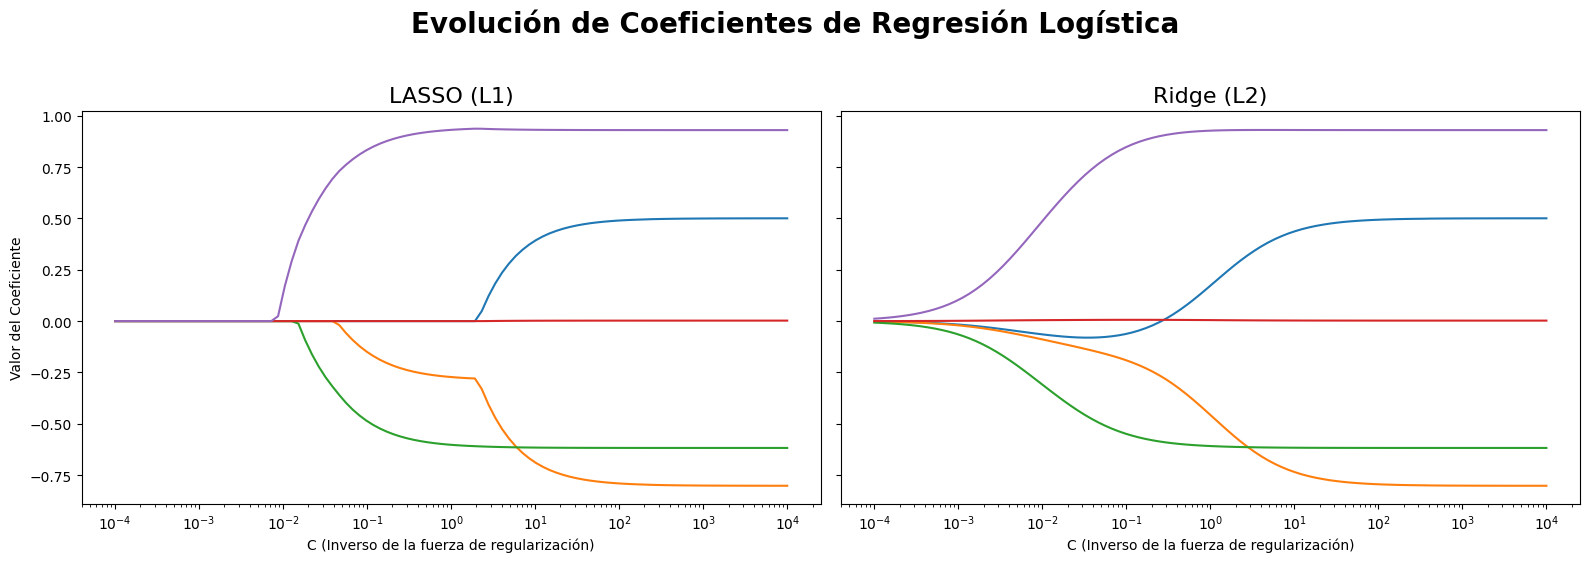

In [9]:
#| label: fig-coefs-ridge-lasso
#| fig-cap: Gráfico con la evolución de los coeficientes para regresión logística con LASSO y Ridge con distintos valores de regularización.
#| echo: false
#| include: true

fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

ax[0].plot(C_grid, coefs_lasso)
ax[0].set_xscale('log')
ax[0].set_title('LASSO (L1)', fontsize=16)
ax[0].set_xlabel('C (Inverso de la fuerza de regularización)')
ax[0].set_ylabel('Valor del Coeficiente')

ax[1].plot(C_grid, coefs_ridge)
ax[1].set_xscale('log')
ax[1].set_title('Ridge (L2)', fontsize=16)
ax[1].set_xlabel('C (Inverso de la fuerza de regularización)')

fig.suptitle('Evolución de Coeficientes de Regresión Logística', fontsize=20, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

## Penalidad óptima por Cross-validation y visualización

Para encontrar el parámetro de regularización óptimo se utilizó la técnica de validación cruzada. Los resultados pueden verse en la @fig-cv-error-ridge-lasso, donde para Ridge el parámetro C óptimo fue de 0.17, mientras que para Lasso, de 0.3.

En ambos casos se observa una curva con la forma de U esperada: el error comienza alto para valores bajos de C (alta penalización), luego disminuye hasta alcanzar un mínimo y, finalmente, vuelve a crecer antes de estabilizarse. Esta estabilización final ocurre porque un valor de C muy grande equivale a una penalización casi nula, por lo que el modelo converge a una Regresión Logística estándar (sin regularización) y sus resultados dejan de cambiar.

In [10]:
reg_log_ridge_cv = LogisticRegressionCV(Cs = C_grid,penalty='l2',solver='saga', cv=5, random_state=444, max_iter=1000)
reg_log_ridge_cv.fit(X_train_scaled, y_train)

reg_log_lasso_cv = LogisticRegressionCV(Cs = C_grid,penalty='l1',solver='saga', cv=5, random_state=444, max_iter=1000)
reg_log_lasso_cv.fit(X_train_scaled, y_train)

,Cs,array([1.0000...00000000e+04])
,fit_intercept,True
,cv,5
,dual,False
,penalty,'l1'
,scoring,None
,solver,'saga'
,tol,0.0001
,max_iter,1000
,class_weight,None
,n_jobs,None


In [11]:
# This is the optimal C value
optimal_c_ridge = reg_log_ridge_cv.C_[0] 
optimal_c_lasso = reg_log_lasso_cv.C_[0] 

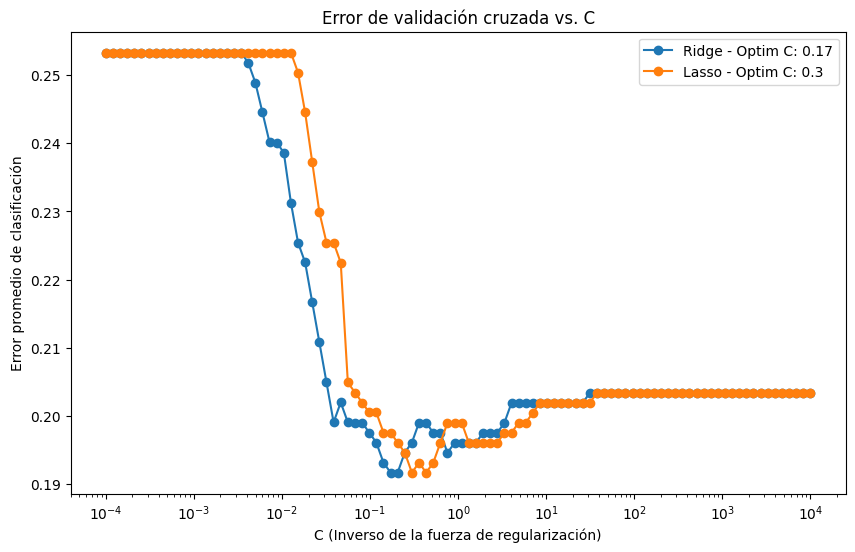

In [12]:
#| label: fig-cv-error-ridge-lasso
#| fig-cap: Gráfico con la evolución del error promedio de clasificación para regresión logística con LASSO y Ridge con distintos valores de regularización evaluado con validación cruzada.
#| echo: false
#| include: true


c_values = reg_log_ridge_cv.Cs_

mean_accuracy_ridge = np.mean(reg_log_ridge_cv.scores_[1], axis=0)
mean_accuracy_lasso = np.mean(reg_log_lasso_cv.scores_[1], axis=0)

mean_classification_error_ridge = 1 - mean_accuracy_ridge
mean_classification_error_lasso = 1 - mean_accuracy_lasso

plt.figure(figsize=(10, 6))
plt.plot(c_values, mean_classification_error_ridge, marker='o', label=f'Ridge - Optim C: {optimal_c_ridge.round(2)}')
plt.plot(c_values, mean_classification_error_lasso, marker='o', label=f'Lasso - Optim C: {optimal_c_lasso.round(2)}')
plt.xlabel('C (Inverso de la fuerza de regularización)')
plt.ylabel('Error promedio de clasificación')
plt.title('Error de validación cruzada vs. C')
plt.xscale('log')
plt.legend()
plt.show()

## Estimacion con $\lambda^{cv}$ y comparacion de coeficientes

Habiendo seleccionado el parámetro de regularización que minimiza el error de validación cruzada, se entrenaron los modelos con esos parámetros y se compararon los coeficientes con la regresión logística no penalizada. Los resultados pueden verse en la @tab-reg-log-coefs, donde queda claro cómo Lasso eliminó los coeficientes asociados a la edad (ch06) y a las horas trabajadas. Es notable nuevamente la diferencia con Ridge, que asignó coeficientes muy bajos a estas variables, pero no las eliminó. Sin embargo, el resto de las variables tienen coeficientes similares entre Ridge y Lasso, pero distintos a los de la regresión sin penalización.

In [13]:
reg_log = LogisticRegression(penalty=None, random_state=42, max_iter=1000)
reg_log.fit(X_train, y_train)
reg_log_ridge = LogisticRegression(C = optimal_c_ridge,penalty='l2', random_state=42, solver='saga', max_iter=1000)
reg_log_ridge.fit(X_train_scaled, y_train)
reg_log_lasso = LogisticRegression(C = optimal_c_ridge, penalty='l1', random_state=42, solver='saga', max_iter=1000)
reg_log_lasso.fit(X_train_scaled, y_train)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,np.float64(0.1707352647470692)
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'saga'
,max_iter,1000
,multi_class,'deprecated'


In [14]:
#| label: tab-reg-log-coefs
#| tab-cap: Tabla con coeficientes para regresión logística sin penalización, con Ridge y con Lasso.
#| echo: false
#| include: true

df_coeffs = pd.DataFrame({
    'Vars': X_train.columns,
    'Sin Penalidad': reg_log.coef_.ravel(),
    'Ridge': reg_log_ridge.coef_.ravel(),
    'Lasso': reg_log_lasso.coef_.ravel() 
}).round(4)

df_coeffs

,Vars,Sin Penalidad,Ridge,Lasso
0,ch06,0.0410,-0.0341,0.0000
1,edad2,-0.0007,-0.2296,-0.2040
2,educ,-0.1604,-0.5740,-0.5380
3,horastrab,0.0000,0.0063,0.0000
4,ix_tot,0.6520,0.8836,0.8766


# Árboles de Decisión

## Estimación

Tras entrenar un árbol de decisión con los datos de entrenamiento, se analizó el efecto del parámetro de costo-complejidad (ccp_alpha). Los resultados pueden verse en la @fig-tree-ccp-alpha, donde se graficó el error de clasificación promedio en función de dicho parámetro. Este parámetro penaliza la complejidad: a mayor sea su valor, los árboles tenderán a ser más pequeños (más "podados"). En cuanto a los resultados, se ve cómo el parámetro que minimiza el error de clasificación es 0.006511.

In [15]:
clf_base = DecisionTreeClassifier(random_state=444)

path = clf_base.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

In [16]:
param_grid = {
    'ccp_alpha': ccp_alphas
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=444),
    param_grid=param_grid,
    cv=10,
    scoring='accuracy'
)

grid_search.fit(X_train_scaled, y_train)

,estimator,DecisionTreeC...dom_state=444)
,param_grid,{'ccp_alpha': array([0. ... 0.03996688])}
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [25]:
best_alpha

np.float64(0.006511353192167162)

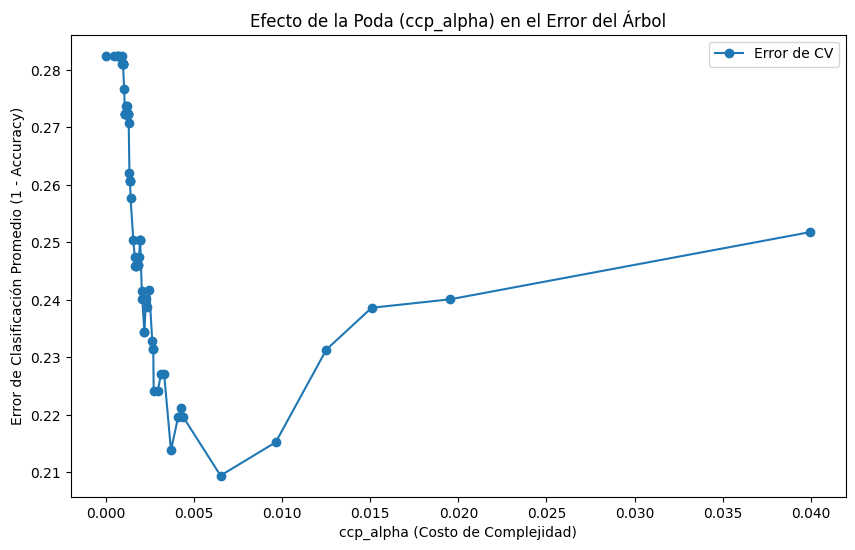

In [17]:
#| label: fig-tree-ccp-alpha
#| fig-cap: Gráfico con error de clasificación promedio en función del parámetro de poda ccp_alpha para el árbol de decisión.
#| echo: false
#| include: true

results = grid_search.cv_results_
mean_accuracy_scores = results['mean_test_score']

mean_classification_error = 1 - mean_accuracy_scores

alphas = results['param_ccp_alpha'].data

plt.figure(figsize=(10, 6))
plt.plot(alphas, mean_classification_error, marker='o', label='Error de CV')

best_alpha = grid_search.best_params_['ccp_alpha']
best_error = 1 - grid_search.best_score_

plt.xlabel('ccp_alpha (Costo de Complejidad)')
plt.ylabel('Error de Clasificación Promedio (1 - Accuracy)')
plt.title('Efecto de la Poda (ccp_alpha) en el Error del Árbol')
plt.legend()
plt.show()

## Visualización del árbol podado por cross-validation

Habiendo seleccionado el costo de complejidad que minimiza el error, se entrenó un árbol de decisión con este valor. La estructura del árbol puede verse en la @fig-tree-importance, donde a la izquierda se observa el árbol principal y a la izquierda las importancias, es decir cuanto las variables ayudaros a disminuir el error de clasificación en el modelo. Comparando las importancias con los coeficientes de la regresión logística penalizada, podemos ver como la cantidad de hijos en el hogar es la variable más importante para predecir se es pobre o no y que las variables eliminadas en las regresiones anteriores tienen poca o nula importancia en este modelo. Eso último valida lo encontrado anteriormente.

In [18]:
feature_names = X_train.columns.tolist() 

class_names = [str(c) for c in sorted(y_train.unique())]

best_pruned_tree = grid_search.best_estimator_

# 1. Obtener las importancias del mejor árbol
importances = best_pruned_tree.feature_importances_

# 2. Crear un DataFrame para facilitar la visualización
feature_importance_df = pd.DataFrame(
    {'feature': feature_names, 'importance': importances}
).sort_values(by='importance', ascending=True) # Ordenar de menor a mayor


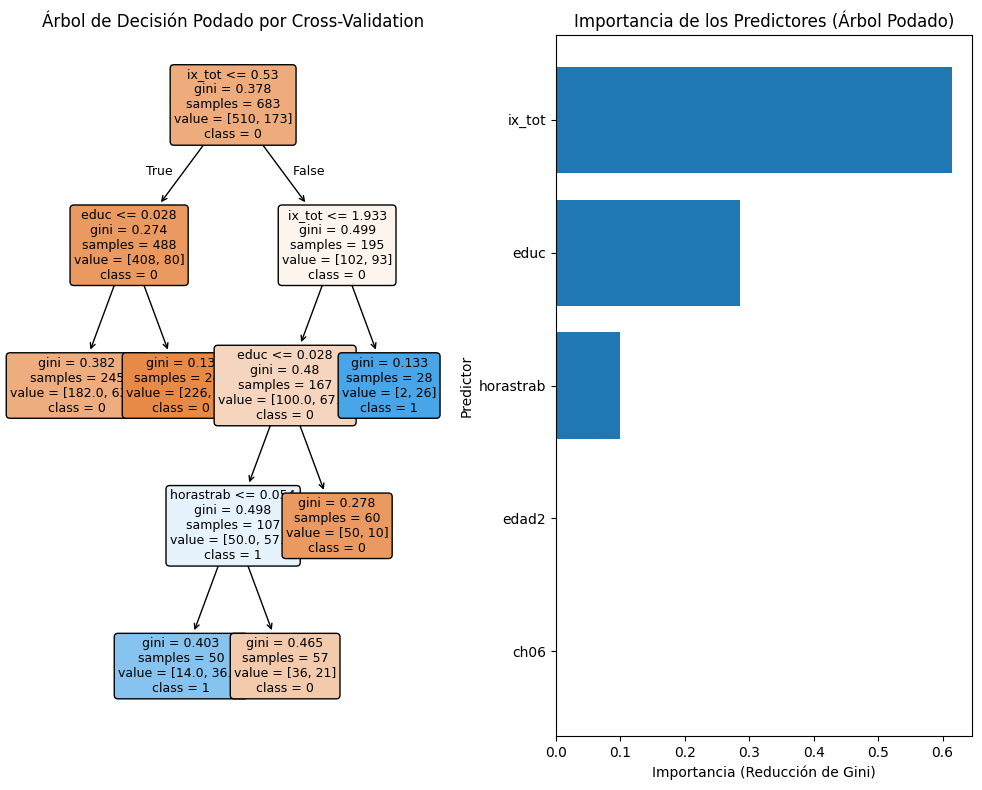

In [19]:
#| label: fig-tree-importance
#| fig-cap: A la derecha se ve el arbol de decision podado por validación cruzada y en el panel de la izquierda la importancia de los predictores.
#| echo: false
#| include: true

fig, ax = plt.subplots(1, 2, figsize=(10, 8)) # Ajusta el tamaño de la figura completa

plot_tree(
    best_pruned_tree,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    precision=3,
    fontsize=9,
    ax=ax[0]   
)
ax[0].set_title("Árbol de Decisión Podado por Cross-Validation")

ax[1].barh(
    feature_importance_df['feature'],
    feature_importance_df['importance']
)
ax[1].set_xlabel("Importancia (Reducción de Gini)")
ax[1].set_ylabel("Predictor")
ax[1].set_title("Importancia de los Predictores (Árbol Podado)")

plt.tight_layout()
plt.show()

# Comparación de métodos

Habiendo entrenado y evaluado los distintos modelos en el conjunto de entrenamiento, se compararon sus resultados en el conjunto de prueba. Los resultados pueden verse en la @tab-metricas-modelos, donde se muestran las métricas de error, accuracy, recall, precision, F1 y ROC AUC para cada uno de los modelos, y en la Figura @fig-roc-curve, donde se comparan sus curvas ROC.

En cuanto a los resultados, se observa que nuevamente los modelos de regresión logística (con y sin penalización) obtienen los mejores resultados en la curva ROC. Sin embargo, dado que el objetivo es identificar grupos vulnerables, es interesante evaluar en detalle el desempeño de los árboles, dado que muestran una sensibilidad mucho más alta que las regresiones. No obstante, la precisión es mucho más baja, lo que indica que si bien los árboles identifican a más pobres, también cometen muchos más errores al hacerlo.

En definitiva, la elección del modelo dependerá de las prioridades del análisis: si se busca minimizar los falsos negativos (maximizar la sensibilidad), los árboles son la mejor opción; pero si se busca un equilibrio entre falsos positivos y falsos negativos, las regresiones logísticas son preferibles.

Al seleccionar un solo modelo, se optaría por la regresión logística sin penalización, ya que obtiene los mejores resultados en la mayoría de las métricas evaluadas, con principal foco en el F1, que balancea la precisión y la sensibilidad. Además, este modelo es el más sencillo de implementar e interpretar, lo que facilita su aplicación práctica y la comunicación de resultados a audiencias no técnicas. Por lo tanto, no se recomienda utilizar modelos más complejos no lineales, como los árboles de decisión, en este caso particular.

Sin embargo, como recomendación adicional, se recomendaría explorar modelos de ensamblado de árboles (como Random Forest o Gradient Boosting) que podrían mejorar el desempeño al combinar múltiples árboles, superando así el rendimiento de un árbol individual. Además, en este trabajo se entrenó a los modelos utilizando la exactitud como métrica de optimización, pero dado el objetivo de identificar grupos vulnerables, podría ser más apropiado utilizar la sensibilidad o el F1 como métrica de optimización durante el entrenamiento.

In [21]:
reg_log_pred = reg_log.predict(X_test)
reg_log_pred_proba = reg_log.predict_proba(X_test)[:, 1]

knn_final = KNeighborsClassifier(n_neighbors=4)
knn_final.fit(X_train, y_train)

knn_pred = knn_final.predict(X_test)
knn_pred_proba = knn_final.predict_proba(X_test)[:, 1] 

X_test_scaled = sc.fit_transform(X_test)

reg_log_ridge_pred = reg_log_ridge.predict(X_test_scaled)
reg_log_ridge_pred_proba = reg_log_ridge.predict_proba(X_test_scaled)[:, 1]

reg_log_lasso_pred = reg_log_lasso.predict(X_test_scaled)
reg_log_lasso_pred_proba = reg_log_lasso.predict_proba(X_test_scaled)[:, 1]

tree_pred = best_pruned_tree.predict(X_test)
tree_pred_proba = best_pruned_tree.predict_proba(X_test)[:, 1]

/Users/mcargnel/Documents/mea/Big-Data-UBA-Grupo-001/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/mcargnel/Documents/mea/Big-Data-UBA-Grupo-001/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


In [22]:
print(pd.crosstab(index=y_test, columns=reg_log_pred).rename(columns={0:'Pred: No Pobre', 1:'Pred: Pobre'}))
print(pd.crosstab(index=y_test, columns=knn_pred).rename(columns={0:'Pred: No Pobre', 1:'Pred: Pobre'}))
print(pd.crosstab(index=y_test, columns=reg_log_ridge_pred).rename(columns={0:'Pred: No Pobre', 1:'Pred: Pobre'}))
print(pd.crosstab(index=y_test, columns=reg_log_lasso_pred).rename(columns={0:'Pred: No Pobre', 1:'Pred: Pobre'}))
print(pd.crosstab(index=y_test, columns=tree_pred).rename(columns={0:'Pred: No Pobre', 1:'Pred: Pobre'}))

col_0  Pred: No Pobre  Pred: Pobre
pobre                             
0                 215           15
1                  39           25
col_0  Pred: No Pobre  Pred: Pobre
pobre                             
0                 223            7
1                  60            4
col_0  Pred: No Pobre  Pred: Pobre
pobre                             
0                 218           12
1                  43           21
col_0  Pred: No Pobre  Pred: Pobre
pobre                             
0                 217           13
1                  43           21
col_0  Pred: No Pobre  Pred: Pobre
pobre                             
0                  79          151
1                   3           61


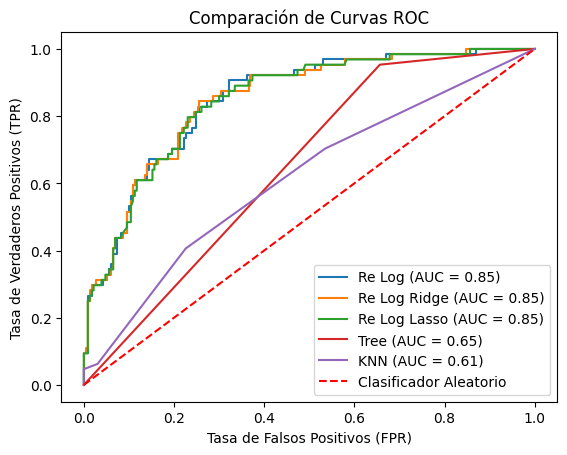

In [23]:
#| label: fig-roc-curve
#| fig-cap: Gráfico con curvas ROC para todos los modelos entrenados.
#| echo: false
#| include: true

fpr_log, tpr_log, _ = roc_curve(y_test, reg_log_pred_proba)
auc_log = roc_auc_score(y_test, reg_log_pred_proba)

fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_pred_proba)
auc_knn = roc_auc_score(y_test, knn_pred_proba)

fpr_log_ridge, tpr_log_ridge, _ = roc_curve(y_test, reg_log_ridge_pred_proba)
auc_log_ridge = roc_auc_score(y_test, reg_log_ridge_pred_proba)

fpr_log_lasso, tpr_log_lasso, _ = roc_curve(y_test, reg_log_lasso_pred_proba)
auc_log_lasso = roc_auc_score(y_test, reg_log_lasso_pred_proba)

fpr_log_tree, tpr_log_tree, _ = roc_curve(y_test, tree_pred_proba)
auc_log_tree = roc_auc_score(y_test, tree_pred_proba)

plt.figure()

plt.plot(fpr_log, tpr_log, label=f'Re Log (AUC = {auc_log:.2f})')

plt.plot(fpr_log_ridge, tpr_log_ridge, label=f'Re Log Ridge (AUC = {auc_log_ridge:.2f})')

plt.plot(fpr_log_lasso, tpr_log_lasso, label=f'Re Log Lasso (AUC = {auc_log_lasso:.2f})')

plt.plot(fpr_log_tree, tpr_log_tree, label=f'Tree (AUC = {auc_log_tree:.2f})')

plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.2f})')

plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Clasificador Aleatorio')

plt.title('Comparación de Curvas ROC')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.legend()

plt.show()

In [27]:
#| label: tab-metrics
#| tab-cap: Tabla con métricas de clasificación para en la muestra de testeo para todos los modelos entrenados.
#| echo: false
#| include: true

metricas = {
    'Reg Log': [
        1- accuracy_score(y_test, reg_log_pred),
        accuracy_score(y_test, reg_log_pred),
        recall_score(y_test, reg_log_pred),
        precision_score(y_test, reg_log_pred),
        f1_score(y_test, reg_log_pred),
        roc_auc_score(y_test, reg_log_pred_proba)
    ],
    'KNN': [
        1- accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, knn_pred),
        recall_score(y_test, knn_pred),
        precision_score(y_test, knn_pred),
        f1_score(y_test, knn_pred),
        roc_auc_score(y_test, knn_pred_proba)
    ],
    'Ridge': [
        1- accuracy_score(y_test, reg_log_ridge_pred),
        accuracy_score(y_test, reg_log_ridge_pred),
        recall_score(y_test, reg_log_ridge_pred),
        precision_score(y_test, reg_log_ridge_pred),
        f1_score(y_test, reg_log_ridge_pred),
        roc_auc_score(y_test, reg_log_ridge_pred_proba)
    ],
    'Lasso': [
        1- accuracy_score(y_test, reg_log_lasso_pred),
        accuracy_score(y_test, reg_log_lasso_pred),
        recall_score(y_test, reg_log_lasso_pred),
        precision_score(y_test, reg_log_lasso_pred),
        f1_score(y_test, reg_log_lasso_pred),
        roc_auc_score(y_test, reg_log_lasso_pred_proba)
    ],
    'Arbol': [
        1- accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, tree_pred),
        recall_score(y_test, tree_pred),
        precision_score(y_test, tree_pred),
        f1_score(y_test, tree_pred),
        roc_auc_score(y_test, tree_pred_proba)
    ]
}

df_resultados = pd.DataFrame(metricas, index=['Error', 'Accuracy', 'Recall', 'Precision', 'F1', 'ROC AUC']).round(3)
df_resultados

,Reg Log,KNN,Ridge,Lasso,Arbol
Error,0.184,0.228,0.187,0.190,0.524
Accuracy,0.816,0.772,0.813,0.810,0.476
Recall,0.391,0.062,0.328,0.328,0.953
Precision,0.625,0.364,0.636,0.618,0.288
F1,0.481,0.107,0.433,0.429,0.442
ROC AUC,0.850,0.615,0.849,0.848,0.648
